In [8]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import AdaBoostClassifier,GradientBoostingClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [9]:
df = pd.read_csv('titanic.csv')

In [10]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [11]:
df.drop(['PassengerId','Name','Ticket','Cabin'],axis=1,inplace=True)

In [12]:
df['Embarked']=df['Embarked'].map({"S":1,"C":0})
df['Sex']=df['Sex'].map({"male":1,"female":0})

In [13]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,1.0
1,1,1,0,38.0,1,0,71.2833,0.0
2,1,3,0,26.0,0,0,7.9250,1.0
3,1,1,0,35.0,1,0,53.1000,1.0
4,0,3,1,35.0,0,0,8.0500,1.0


In [14]:
df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked     79
dtype: int64

In [29]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [30]:
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])

In [31]:
df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [32]:
df.describe()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,0.647587,28.566970,0.523008,0.381594,32.204208,0.811448
std,0.486592,0.836071,0.477990,13.199572,1.102743,0.806057,49.693429,0.391372
min,0.000000,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,0.000000,22.000000,0.000000,0.000000,7.910400,1.000000
50%,0.000000,3.000000,1.000000,24.000000,0.000000,0.000000,14.454200,1.000000
75%,1.000000,3.000000,1.000000,35.000000,1.000000,0.000000,31.000000,1.000000
max,1.000000,3.000000,1.000000,80.000000,8.000000,6.000000,512.329200,1.000000


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    int64  
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    float64
dtypes: float64(3), int64(5)
memory usage: 55.8 KB


In [34]:
df.shape

(891, 8)

In [35]:
X = df.drop("Survived",axis=1)
y = df['Survived']

In [36]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)                     

In [37]:
model = AdaBoostClassifier(n_estimators=100)
model.fit(X_train,y_train)

,estimator,None
,n_estimators,100
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,None


In [38]:
y_pred=model.predict(X_test)

In [40]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test,y_pred))

Accuracy: 0.8044692737430168
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179

[[90 15]
 [20 54]]


In [44]:
model1 = GradientBoostingClassifier()
model1.fit(X_train,y_train)
y_pred1=model1.predict(X_test)
print("Accuracy:",accuracy_score(y_test,y_pred1))
print(classification_report(y_test,y_pred1))
print("confusion_matrix:",confusion_matrix(y_test,y_pred1))

Accuracy: 0.8044692737430168
              precision    recall  f1-score   support

           0       0.81      0.87      0.84       105
           1       0.79      0.72      0.75        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179

confusion_matrix: [[91 14]
 [21 53]]


In [45]:
model2=XGBClassifier()
model2.fit(X_train,y_train)
y_pred2=model2.predict(X_test)
print("Accuracy:",accuracy_score(y_test,y_pred2))
print(classification_report(y_test,y_pred2))
print("confusion_matrix:",confusion_matrix(y_test,y_pred2))

Accuracy: 0.7932960893854749
              precision    recall  f1-score   support

           0       0.81      0.84      0.83       105
           1       0.76      0.73      0.74        74

    accuracy                           0.79       179
   macro avg       0.79      0.78      0.79       179
weighted avg       0.79      0.79      0.79       179

confusion_matrix: [[88 17]
 [20 54]]


In [47]:
model3 = LGBMClassifier()
model3.fit(X_train,y_train)
y_pred3 = model3.predict(X_test)
print("Accuracy:",accuracy_score(y_test,y_pred3))
print(classification_report(y_test,y_pred3))
print("confusion_matrix:",confusion_matrix(y_test,y_pred3))

[LightGBM] [Info] Number of positive: 268, number of negative: 444
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000385 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 193
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.376404 -> initscore=-0.504838
[LightGBM] [Info] Start training from score -0.504838
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [48]:
model4=CatBoostClassifier()
model4.fit(X_train,y_train)
y_pred4=model4.predict(X_test)
print("Accuracy:",accuracy_score(y_test,y_pred4))
print(classification_report(y_test,y_pred4))
print("confusion_matrix:",confusion_matrix(y_test,y_pred4))

Learning rate set to 0.008911
0:	learn: 0.6870240	total: 58.6ms	remaining: 58.5s
1:	learn: 0.6812459	total: 60.8ms	remaining: 30.3s
2:	learn: 0.6753713	total: 61.9ms	remaining: 20.6s
3:	learn: 0.6694174	total: 63.4ms	remaining: 15.8s
4:	learn: 0.6644566	total: 64.1ms	remaining: 12.8s
5:	learn: 0.6587346	total: 65.2ms	remaining: 10.8s
6:	learn: 0.6554674	total: 65.9ms	remaining: 9.34s
7:	learn: 0.6498249	total: 67.2ms	remaining: 8.33s
8:	learn: 0.6442850	total: 68.2ms	remaining: 7.51s
9:	learn: 0.6402784	total: 69.3ms	remaining: 6.86s
10:	learn: 0.6346471	total: 70.3ms	remaining: 6.32s
11:	learn: 0.6294316	total: 71.4ms	remaining: 5.88s
12:	learn: 0.6248813	total: 72.2ms	remaining: 5.48s
13:	learn: 0.6201295	total: 73.1ms	remaining: 5.15s
14:	learn: 0.6148979	total: 74ms	remaining: 4.86s
15:	learn: 0.6116979	total: 74.6ms	remaining: 4.59s
16:	learn: 0.6075262	total: 75.5ms	remaining: 4.37s
17:	learn: 0.6042375	total: 76.4ms	remaining: 4.17s
18:	learn: 0.6005835	total: 77.2ms	remaining: 

In [49]:
models = {
    "AdaBoost": AdaBoostClassifier(),
    "GradientBoost": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(),
    "LightGBM": LGBMClassifier(),
    "CatBoost": CatBoostClassifier(verbose=0)
}

for name, model in models.items():
    
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    
    print(name, accuracy_score(y_test, pred))

AdaBoost 0.7988826815642458
GradientBoost 0.8044692737430168
XGBoost 0.7932960893854749
[LightGBM] [Info] Number of positive: 268, number of negative: 444
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000318 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 193
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.376404 -> initscore=-0.504838
[LightGBM] [Info] Start training from score -0.504838
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

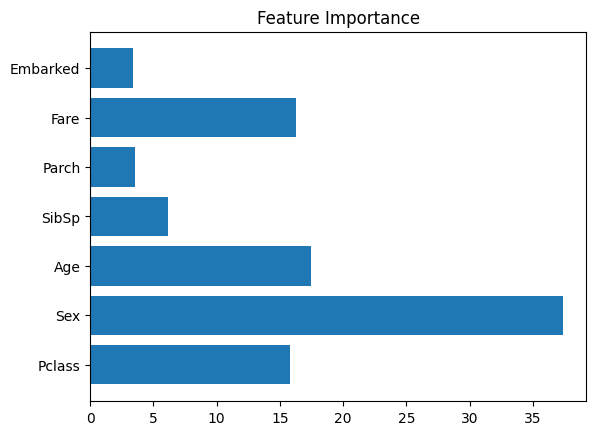

In [50]:
importance = model.feature_importances_
plt.barh(X.columns, importance)
plt.title("Feature Importance")
plt.show()

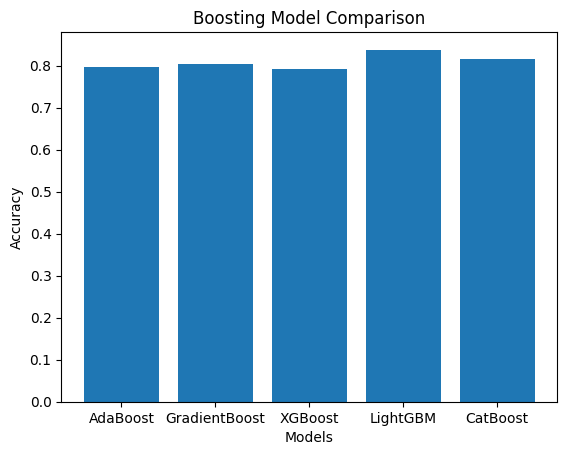

In [51]:
import matplotlib.pyplot as plt

models = ["AdaBoost","GradientBoost","XGBoost","LightGBM","CatBoost"]
accuracy = [0.798,0.804,0.793,0.838,0.816]

plt.bar(models,accuracy)

plt.title("Boosting Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()